# 01 — Data Exploration
Inspect the dataset: image counts, mask quality, keypoint distribution, and class balance.

In [87]:
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

with open('../data/dataset.json') as f:
    data = json.load(f)

print(f"Train: {len(data['train'])} | Val: {len(data['val'])} | Test: {len(data['test'])}")
print(f"Keypoints: {data['keypoint_names']}")

Train: 2968 | Val: 371 | Test: 371
Keypoints: ['nose', 'shoulder', 'tail']


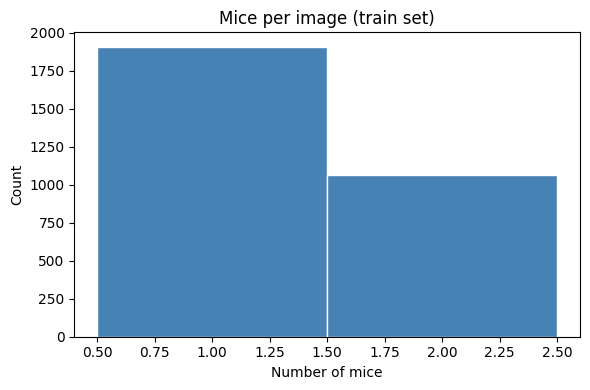

In [88]:
# Count mice per image
mice_counts = [len(item['all_keypoints']) for item in data['train']]
plt.figure(figsize=(6, 4))
plt.hist(mice_counts, bins=range(1, max(mice_counts)+2), align='left', color='steelblue', edgecolor='white')
plt.title('Mice per image (train set)')
plt.xlabel('Number of mice')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

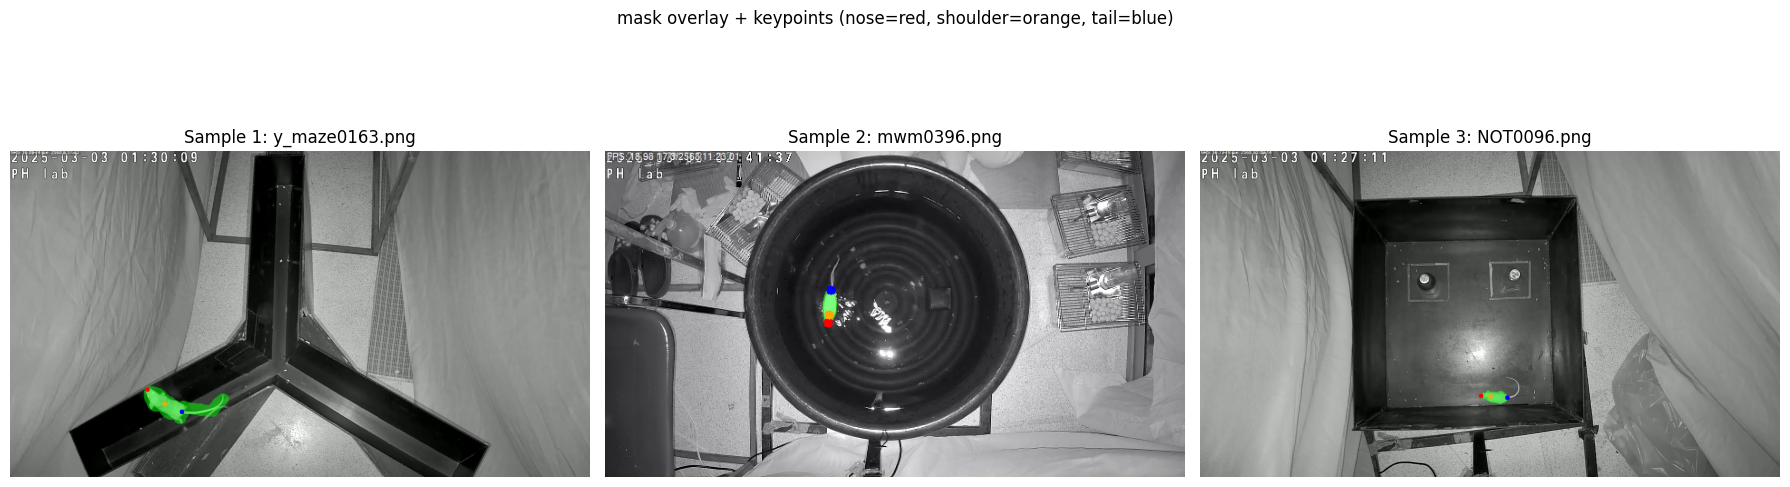

In [89]:
import random

# Visualise 3 random samples: image + mask overlay + keypoints
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
samples = random.sample(data['train'], 3)

for i, sample in enumerate(samples):
    sample['image_path'] = '../' + sample['image_path'].replace('\\', '/')
    img = cv2.cvtColor(cv2.imread(sample['image_path']), cv2.COLOR_BGR2RGB)
    combined_mask = np.zeros(img.shape[:2], dtype=np.uint8)
    for m_path in sample['mask_paths']:
        m_path = '../' + m_path.replace('\\', '/')
        m = cv2.imread(m_path, cv2.IMREAD_GRAYSCALE)
        if m is not None:
            combined_mask = np.maximum(combined_mask, m)
    overlay = img.copy()
    overlay[combined_mask > 0] = (overlay[combined_mask > 0] * 0.5 + np.array([0, 255, 0]) * 0.5).astype(np.uint8)
    kp_colors = [(255, 0, 0), (255, 165, 0), (0, 0, 255)]
    for mouse_kps in sample['all_keypoints']:
        for k, (x, y) in enumerate(mouse_kps):
            if x > 0 and y > 0:
                cv2.circle(overlay, (int(x), int(y)), 5, kp_colors[k], -1)
    axes[i].imshow(overlay)
    axes[i].set_title(f'Sample {i+1}: {Path(sample["image_path"]).name}')
    axes[i].axis('off')

plt.suptitle('mask overlay + keypoints (nose=red, shoulder=orange, tail=blue)')
plt.tight_layout()
plt.show()

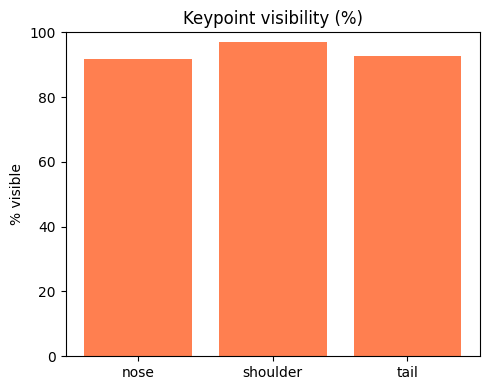

In [90]:
# Keypoint visibility stats
kp_names = data['keypoint_names']
visibility = {k: 0 for k in kp_names}
total = 0

for split in ['train', 'val', 'test']:
    for item in data[split]:
        for mouse_kps in item['all_keypoints']:
            total += 1
            for i, (x, y) in enumerate(mouse_kps):
                if x > 0 and y > 0:
                    visibility[kp_names[i]] += 1

plt.figure(figsize=(5, 4))
plt.bar(visibility.keys(), [v/total*100 for v in visibility.values()], color='coral')
plt.title('Keypoint visibility (%)')
plt.ylabel('% visible')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()